<a href="https://colab.research.google.com/github/websterj3-sketch/QLC140Spring26/blob/main/Exercise5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import the packages needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import both tide data files

# Plot both data on the same plot


Successfully loaded both tide data files.


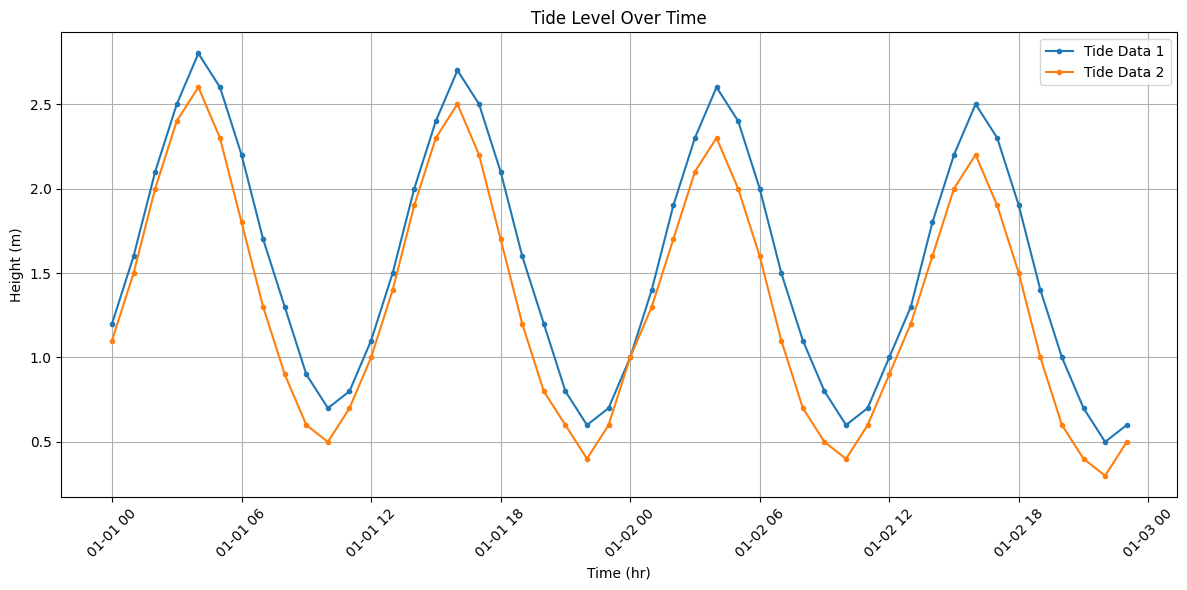

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data from the specified files
try:
    df1 = pd.read_csv('/content/time_hr,height_m.txt')
    df2 = pd.read_csv('/content/time_hr,height_m_2.txt')
    print("Successfully loaded both tide data files.")
except FileNotFoundError as e:
    print(f"Error loading file: {e}. Please ensure the files are in the correct path.")
    df1 = None
    df2 = None

if df1 is not None and df2 is not None:
    # Rename columns to a consistent format if they are not already 'time_hr' and 'height_m'
    # Assuming the first column is time_hr and second is height_m
    if len(df1.columns) == 2:
        df1.columns = ['time_hr', 'height_m']
    if len(df2.columns) == 2:
        df2.columns = ['time_hr', 'height_m']

    # Convert 'time_hr' column to datetime objects
    df1['time_hr'] = pd.to_datetime(df1['time_hr'], unit='h') # Assuming 'hr' means hours from epoch or similar, adjust if needed
    df2['time_hr'] = pd.to_datetime(df2['time_hr'], unit='h') # Adjust 'unit' if time is in a different format

    # Plot both data on the same plot
    plt.figure(figsize=(12, 6))

    plt.plot(df1['time_hr'], df1['height_m'], label='Tide Data 1', marker='.')
    plt.plot(df2['time_hr'], df2['height_m'], label='Tide Data 2', marker='.')

    plt.xlabel('Time (hr)')
    plt.ylabel('Height (m)')
    plt.title('Tide Level Over Time')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Plotting skipped due to missing or unreadable data files.")

I think these are mixed semidiurnal tides because there are two high tides and two low tides in 24 hours, but the heights vary. These tides could be located in the Carribean or near Greenland, where semidiurnal tides are common.

In [ ]:
# Import packages needed to run code
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df_nitrate = pd.read_csv('/content/jma_nitrate (1).csv')
display(df_nitrate.head())

,Unnamed: 0,theta,sal,depth,nitrate,lon,lat,date,year,month,day,profile,cruise,vessel,density
0,0,25.8807,34.0215,0,0.09,140.242833,34.926167,2010/10/03,2010.0,10.0,3.0,1.0,10-07,R/V Keifu Maru,22.228287
1,1,25.8993,34.0217,13,0.00,140.242833,34.926167,2010/10/03,2010.0,10.0,3.0,1.0,10-07,R/V Keifu Maru,22.222695
2,2,25.8843,34.0196,27,0.00,140.242833,34.926167,2010/10/03,2010.0,10.0,3.0,1.0,10-07,R/V Keifu Maru,22.225773
3,3,25.9894,34.2936,51,0.48,140.242833,34.926167,2010/10/03,2010.0,10.0,3.0,1.0,10-07,R/V Keifu Maru,22.395633
4,4,23.6146,34.5002,75,2.71,140.242833,34.926167,2010/10/03,2010.0,10.0,3.0,1.0,10-07,R/V Keifu Maru,23.263277


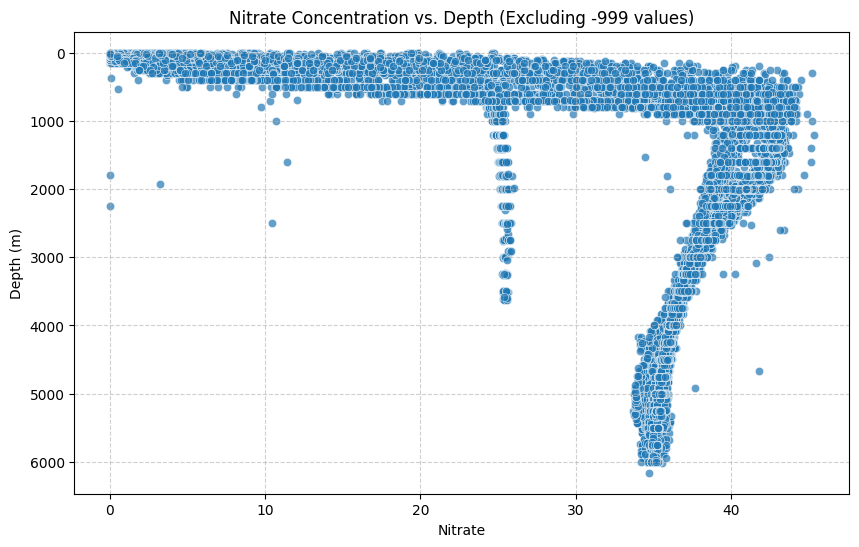

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out -999 nitrate values
df_nitrate_filtered = df_nitrate[df_nitrate['nitrate'] != -999]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_nitrate_filtered, x='nitrate', y='depth', alpha=0.7)
plt.xlabel('Nitrate')
plt.ylabel('Depth (m)')
plt.title('Nitrate Concentration vs. Depth (Excluding -999 values)')
plt.gca().invert_yaxis() # Invert y-axis for depth plots
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Reading in the Argo float data with no NO3 values
infile = '/content/kuro_BGCargo_noNO3 (1) (1).csv'
data_BGC = pd.read_csv(infile, sep = (','))

# Separating the data column of BGC argo data into year month and day columns
import datetime

data_BGC['year'] = pd.DatetimeIndex(data_BGC['Date/GMT']).year
data_BGC['month'] = pd.DatetimeIndex(data_BGC['Date/GMT']).month
data_BGC['day'] = pd.DatetimeIndex(data_BGC['Date/GMT']).day
data_BGC.head()

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,Date/GMT,Days since 1/1/1900,DEPTH[M],PRESSURE[DBAR],NA,SALINITY[PSS],TEMPERATURE[C],SIGMATHETA[KG/M3],OXYGEN[uMOL/KG],OXYGENSAT,LON,LAT,year,month,day
0,03/02/2013 13:38,41335.568,-989.324,-999.09,3,34.3676,3.2285,27.366,35.1,10.9,148.688,36.983,2013,3,2
1,03/02/2013 13:38,41335.568,-941.762,-950.95,3,34.3560,3.3824,27.342,39.2,12.2,148.688,36.983,2013,3,2
2,03/02/2013 13:38,41335.568,-892.728,-901.33,3,34.3380,3.4966,27.316,40.2,12.6,148.688,36.983,2013,3,2
3,03/02/2013 13:38,41335.568,-842.920,-850.94,3,34.2972,3.4847,27.284,35.5,11.1,148.688,36.983,2013,3,2
4,03/02/2013 13:38,41335.568,-794.287,-801.75,3,34.2942,3.6554,27.265,38.6,12.1,148.688,36.983,2013,3,2


In [2]:
import pandas as pd
infile_2 = '/content/kuro_BGCargo_noNO3 (1).csv'
data_BGC2 = pd.read_csv(infile_2, sep = (','))
display(data_BGC2.head())

,Date/GMT,Days since 1/1/1900,DEPTH[M],PRESSURE[DBAR],NA,SALINITY[PSS],TEMPERATURE[C],SIGMATHETA[KG/M3],OXYGEN[uMOL/KG],OXYGENSAT,LON,LAT
0,03/02/2013 13:38,41335.568,-989.324,-999.09,3,34.3676,3.2285,27.366,35.1,10.9,148.688,36.983
1,03/02/2013 13:38,41335.568,-941.762,-950.95,3,34.3560,3.3824,27.342,39.2,12.2,148.688,36.983
2,03/02/2013 13:38,41335.568,-892.728,-901.33,3,34.3380,3.4966,27.316,40.2,12.6,148.688,36.983
3,03/02/2013 13:38,41335.568,-842.920,-850.94,3,34.2972,3.4847,27.284,35.5,11.1,148.688,36.983
4,03/02/2013 13:38,41335.568,-794.287,-801.75,3,34.2942,3.6554,27.265,38.6,12.1,148.688,36.983


In [ ]:
#Plot the corrected data and the Argo float data "Latitude" and "Longitude" coordinates
#If you're unsure of the column to choose, just look at the data and the column head names.
#Scatter plot for example

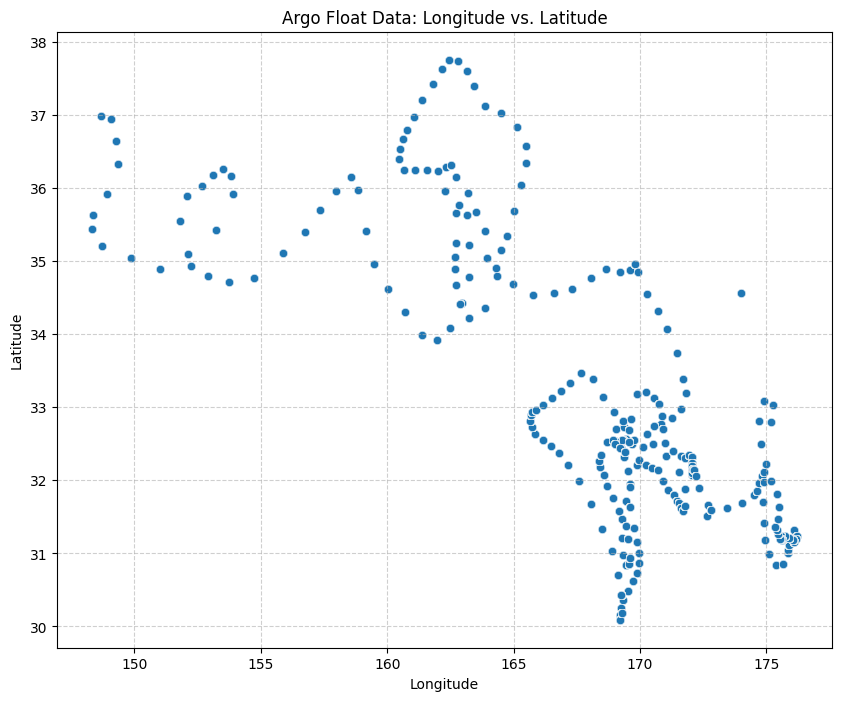

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(data=data_BGC, x='LON', y='LAT', alpha=0.7)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Argo Float Data: Longitude vs. Latitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

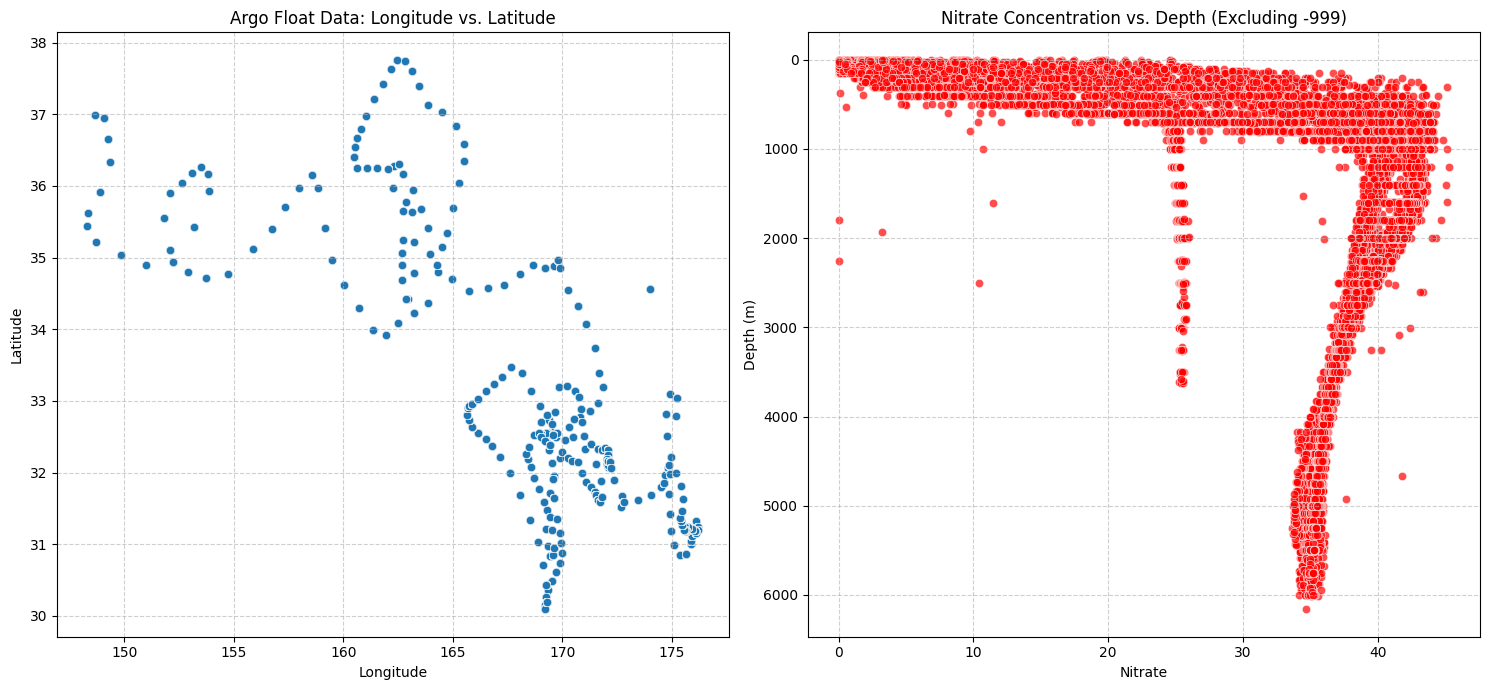

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))

# Subplot 1: Argo Float Data: Longitude vs. Latitude
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.scatterplot(data=data_BGC, x='LON', y='LAT', alpha=0.7)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Argo Float Data: Longitude vs. Latitude')
plt.grid(True, linestyle='--', alpha=0.6)

# Subplot 2: Nitrate Concentration vs. Depth (Excluding -999 values)
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.scatterplot(data=df_nitrate_filtered, x='nitrate', y='depth', alpha=0.7, color='red')
plt.xlabel('Nitrate')
plt.ylabel('Depth (m)')
plt.title('Nitrate Concentration vs. Depth (Excluding -999)')
plt.gca().invert_yaxis() # Invert y-axis for depth plots
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

Since overlaying geographical coordinates with depth profiles on the same axes is not standard, I will demonstrate how to overlay two vertical profiles: Nitrate concentration and Oxygen concentration against depth. Both datasets contain depth information.

/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_base.py:3024: RuntimeWarning: overflow encountered in scalar add
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


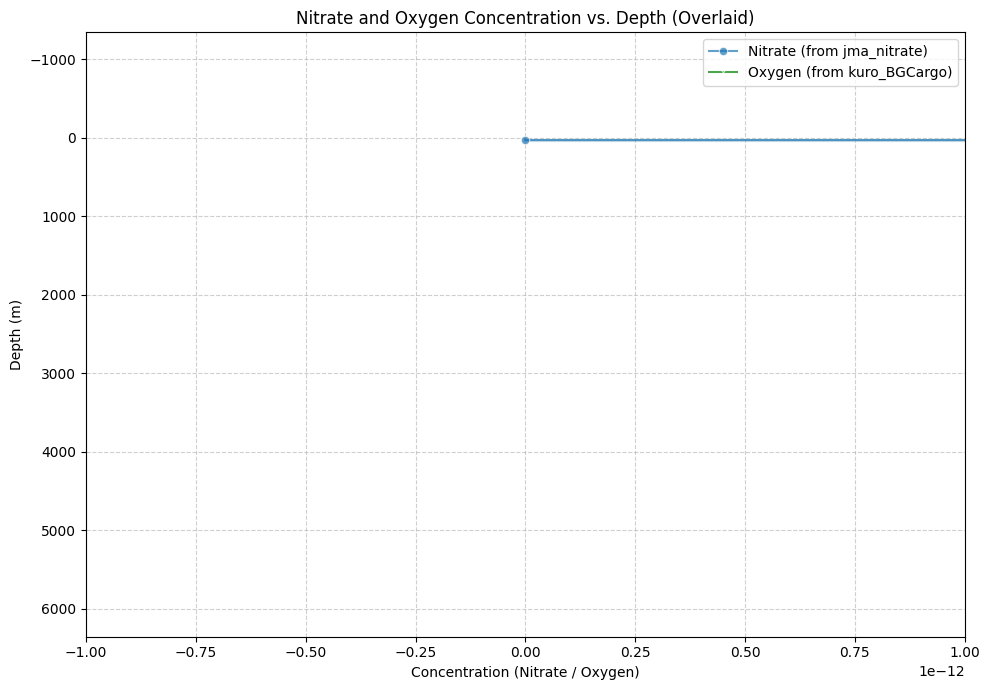

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

# Plot Nitrate vs Depth
sns.lineplot(data=df_nitrate_filtered, x='nitrate', y='depth', label='Nitrate (from jma_nitrate)', marker='o', alpha=0.7)

# Plot Oxygen vs Depth from data_BGC
# Filter out -999 values for depth and oxygen if they exist in data_BGC
data_BGC_filtered = data_BGC[(data_BGC['DEPTH[M]'] != -999) & (data_BGC['OXYGEN[uMOL/KG]'] != -999)]
sns.lineplot(data=data_BGC_filtered, x='OXYGEN[uMOL/KG]', y='DEPTH[M]', label='Oxygen (from kuro_BGCargo)', marker='x', alpha=0.7, color='green')

plt.xlabel('Concentration (Nitrate / Oxygen)')
plt.ylabel('Depth (m)')
plt.title('Nitrate and Oxygen Concentration vs. Depth (Overlaid)')
plt.gca().invert_yaxis() # Invert y-axis for depth plots
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
#Plot a scatter plot looking at the temperature vs. depth profile and separate plot looking at salinity vs temperature. Each data source should be labeled differently

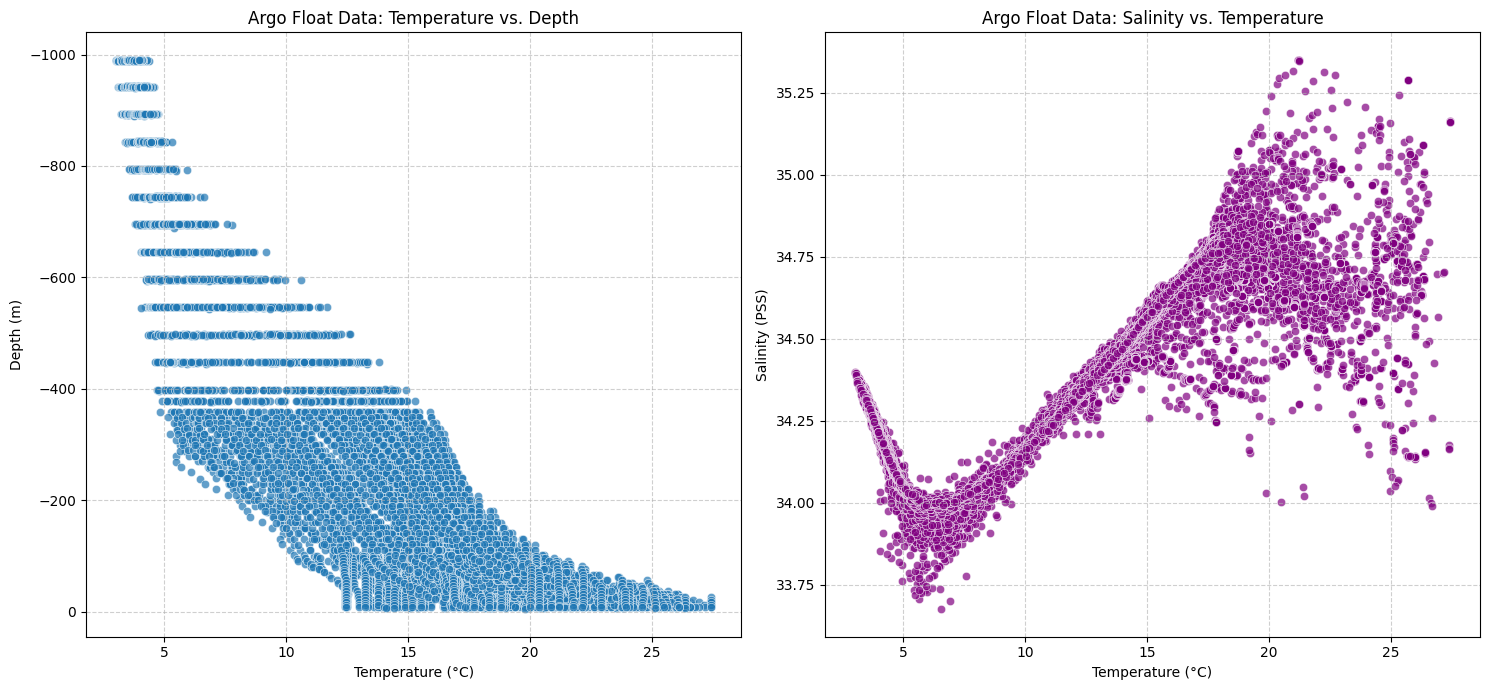

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out -999 values from data_BGC for relevant columns
data_BGC_filtered_temp_depth = data_BGC[(data_BGC['DEPTH[M]'] != -999) & (data_BGC['TEMPERATURE[C]'] != -999)]
data_BGC_filtered_sal_temp = data_BGC[(data_BGC['SALINITY[PSS]'] != -999) & (data_BGC['TEMPERATURE[C]'] != -999)]

plt.figure(figsize=(15, 7))

# Subplot 1: Temperature vs. Depth profile
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.scatterplot(data=data_BGC_filtered_temp_depth, x='TEMPERATURE[C]', y='DEPTH[M]', alpha=0.7)
plt.xlabel('Temperature (°C)')
plt.ylabel('Depth (m)')
plt.title('Argo Float Data: Temperature vs. Depth')
plt.gca().invert_yaxis() # Invert y-axis for depth plots
plt.grid(True, linestyle='--', alpha=0.6)

# Subplot 2: Salinity vs. Temperature
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.scatterplot(data=data_BGC_filtered_sal_temp, x='TEMPERATURE[C]', y='SALINITY[PSS]', alpha=0.7, color='purple')
plt.xlabel('Temperature (°C)')
plt.ylabel('Salinity (PSS)')
plt.title('Argo Float Data: Salinity vs. Temperature')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [18]:
#import the jma nitrate file, then get columns I want for training
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

infile = 'jma_nitrate (1).csv'
nitratefile = pd.read_csv(infile, sep = (','))
nitratefilefiltered = nitratefile[nitratefile.nitrate>0]
nitratefilefiltered = nitratefilefiltered[["sal","theta","nitrate"]]
nitratefilefiltered.head()
X = nitratefilefiltered[["sal","theta"]]
Y = nitratefilefiltered [["nitrate"]]
print(np.shape(X))
print(np.shape(Y))

# split data set to train/test 20/80 split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=4)

(15574, 2)
(15574, 1)


In [31]:
# pick model
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

#run KNN with K neighbors ranging from 1-15, calculating r2 and RMSE to find the best fit model
results = []
for n in range(1,16):
    model = KNeighborsRegressor(n_neighbors=n)
    res = []
    model.fit(X_train, Y_train)
    #print ('Neighbors = %s/n' % (int(n)))
    #compute the R^2 score
    accuracyscore = model.score(X_train, Y_train)
    #print(Training "R^2 score: {0:.2f}/n".format(model.score(X_train, Y_train)))
    #plot the model together with the data
    xfit = X_test
    yfit = model.predict(xfit)
    #print(Training "R^2 score: {0:.2f}/n".format(model.score(xfit,yfit)))
    rmse = sqrt(mean_squared_error(Y_test, yfit))
    #print(Training "RMSE: {0:.2f}/n".format(rmse))
    res = [n,accuracyscore,rmse]
    results.append(res)



In [20]:
results

[[1, 0.9999110613989356, 2.6058678198832435],
 [2, 0.9927289125889681, 2.4303135395420776],
 [3, 0.989436962483429, 2.320717656355632],
 [4, 0.9877493952444761, 2.294790385486795],
 [5, 0.9862445125445002, 2.265924014995549],
 [6, 0.9853651009567571, 2.2178185162292237],
 [7, 0.9846615070565908, 2.213675727092634],
 [8, 0.9840785865559012, 2.1952765454848047],
 [9, 0.9836823893549954, 2.20225936338761],
 [10, 0.9833161917430909, 2.1939401652725508],
 [11, 0.9830143132143836, 2.2023368473610616],
 [12, 0.98254256174158, 2.2144196381599355],
 [13, 0.9820371954017075, 2.2041353557622165],
 [14, 0.9816750176585883, 2.208859357144669],
 [15, 0.9812961480610605, 2.2152382383662066]]

In [27]:
#Run best fit model, and display results
model = KNeighborsRegressor(n_neighbors=13)
model.fit(X_train, Y_train)
print ('Neighbors = %s/n' % (13))
  #compute the R^2 score
accuracyscore = model.score(X_train, Y_train)
print("Training R^2 score: {0:.2f}/n".format(model.score(X_train, Y_train)))
  #plot the model together with the data
xfit = X_test
yfit = model.predict(xfit)
print("Training R^2 score: {0:.2f}/n".format(model.score(xfit,yfit)))
rmse = sqrt(mean_squared_error(Y_test, yfit))
print("RMSE: {0:.2f}/n".format(rmse))

Neighbors = 13/n
Training R^2 score: 0.98/n
Training R^2 score: 1.00/n
RMSE: 2.20/n


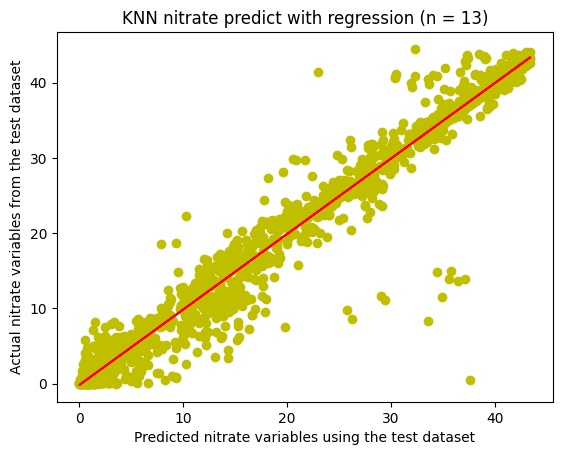

r2 = 0.9999503303754949 /n
RMSE = 0.10719952265086939 /n


In [32]:
#Plot predicted nitrate from test compared to actual nitrate from test
#this is using the best fit model from above
from sklearn.linear_model import LinearRegression
plt.scatter(yfit,Y_test,color = 'y')
linear_regressor = LinearRegression() # create object for the class
linear_regressor.fit(yfit, Y_test) # perform linear regression
Y_pred = linear_regressor.predict(yfit) # make predictions
plt.plot(yfit, Y_pred, color = 'red')
plt.xlabel("Predicted nitrate variables using the test dataset")
plt.ylabel("Actual nitrate variables from the test dataset")
plt.title("KNN nitrate predict with regression (n = 13)")
plt.show()
r2 = r2_score(yfit, Y_pred)
print("r2 = %s /n" % (r2))
rmse = sqrt(mean_squared_error(yfit, Y_pred))
print("RMSE = %s /n" % (rmse))
#The plot and r2/RMSE values above show that the predicted nitrae values for the